In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape


(7043, 21)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='Churn', ylabel='Count'>

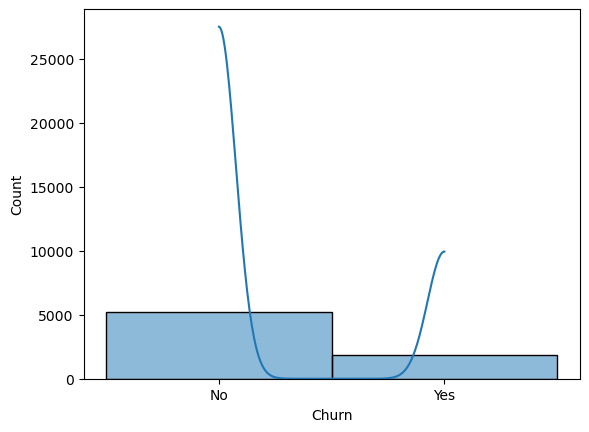

In [9]:
sns.histplot(df['Churn'],bins = 50,kde = True)


<Axes: >

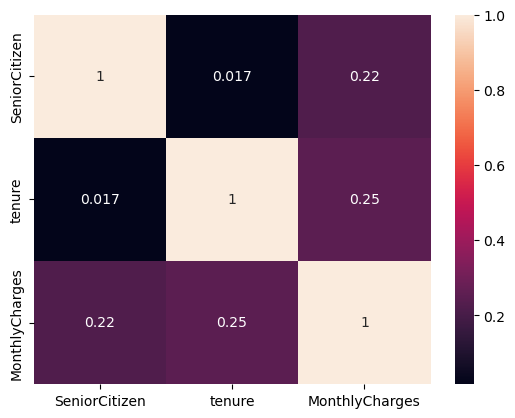

In [10]:
sns.heatmap(df.corr(numeric_only = True),annot = True)


(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

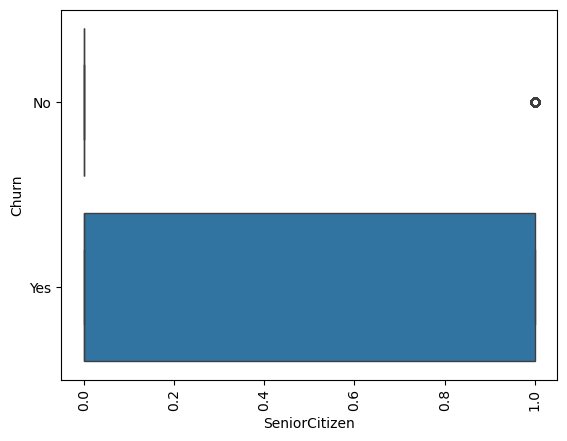

In [11]:
sns.boxplot(data = df, x = 'SeniorCitizen', y = 'Churn')
plt.xticks(rotation = 90)

<Axes: xlabel='MonthlyCharges', ylabel='Churn'>

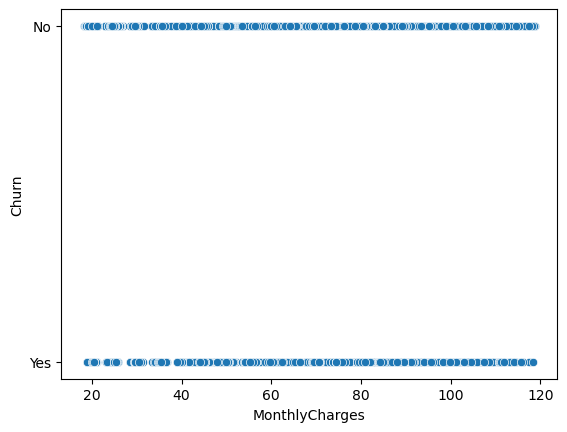

In [12]:
sns.scatterplot(data = df, x = 'MonthlyCharges',y = 'Churn')


<Axes: xlabel='tenure', ylabel='Churn'>

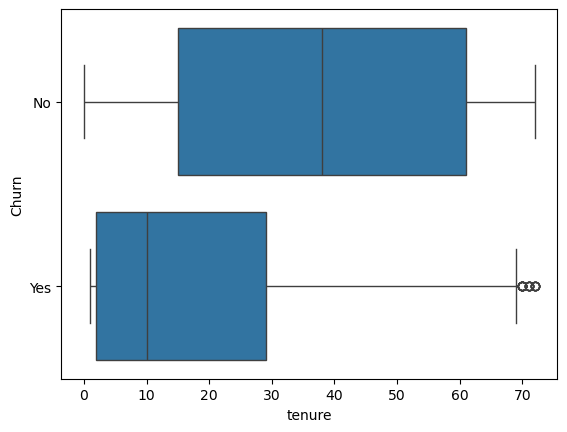

In [13]:
sns.boxplot(data = df, x = 'tenure', y = 'Churn')


<Axes: xlabel='Contract', ylabel='Churn'>

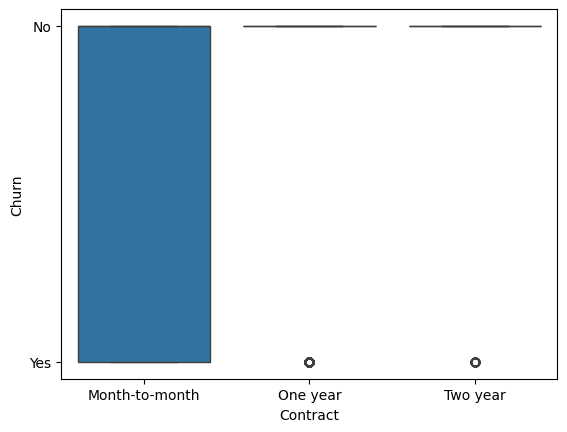

In [14]:
sns.boxplot(data = df, x = 'Contract',y = 'Churn')


In [15]:
X = df.drop(columns = ['Churn','customerID' ],axis = 1)
y = df['Churn']
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6


In [16]:
cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges'
]

for col in cols:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
N

In [17]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:

X_one_encode = pd.get_dummies(X,columns = ['gender','MultipleLines','OnlineBackup','OnlineSecurity', 'InternetService','Contract','PaymentMethod','DeviceProtection','StreamingMovies' ,'TechSupport',
       'StreamingTV'],drop_first = True)

In [19]:
X_one_encode.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes
0,0,Yes,No,1,No,Yes,29.85,29.85,False,True,...,True,False,False,False,False,False,False,False,False,False
1,0,No,No,34,Yes,No,56.95,1889.5,True,False,...,False,True,False,True,False,False,False,False,False,False
2,0,No,No,2,Yes,Yes,53.85,108.15,True,False,...,False,True,False,False,False,False,False,False,False,False
3,0,No,No,45,No,No,42.30,1840.75,True,True,...,False,False,False,True,False,False,False,True,False,False
4,0,No,No,2,Yes,Yes,70.70,151.65,False,False,...,True,False,False,False,False,False,False,False,False,False


In [20]:
X_one_encode['Partner'] = X_one_encode['Partner'].map({"No" : 0,"Yes" : 1})

In [21]:
X_one_encode.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes
0,0,1,No,1,No,Yes,29.85,29.85,False,True,...,True,False,False,False,False,False,False,False,False,False
1,0,0,No,34,Yes,No,56.95,1889.5,True,False,...,False,True,False,True,False,False,False,False,False,False
2,0,0,No,2,Yes,Yes,53.85,108.15,True,False,...,False,True,False,False,False,False,False,False,False,False
3,0,0,No,45,No,No,42.30,1840.75,True,True,...,False,False,False,True,False,False,False,True,False,False
4,0,0,No,2,Yes,Yes,70.70,151.65,False,False,...,True,False,False,False,False,False,False,False,False,False


In [22]:
Col1 = X_one_encode.columns
for Col1 in Col1:
    print(f"\n{Col1}")
    print(X_one_encode[Col1].value_counts())


SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
Partner
0    3641
1    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

PaperlessBilling
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

MonthlyCharges
MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
23.65      1
114.70     1
43.65      1
87.80      1
78.70      1
Name: count, Length: 1585, dtype: int64

TotalCharges
TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

gender_Male
gender_Male
True     3555
F

In [23]:
binary_cols = [
    'Dependents',
    'PaperlessBilling',
    'PhoneService',
    
]

for col in binary_cols:
    X_one_encode[col] = X_one_encode[col].map({'No': 0, 'Yes': 1})

In [24]:
X_one_encode.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes
0,0,1,0,1,0,1,29.85,29.85,False,True,...,True,False,False,False,False,False,False,False,False,False
1,0,0,0,34,1,0,56.95,1889.5,True,False,...,False,True,False,True,False,False,False,False,False,False
2,0,0,0,2,1,1,53.85,108.15,True,False,...,False,True,False,False,False,False,False,False,False,False
3,0,0,0,45,0,0,42.30,1840.75,True,True,...,False,False,False,True,False,False,False,True,False,False
4,0,0,0,2,1,1,70.70,151.65,False,False,...,True,False,False,False,False,False,False,False,False,False


In [25]:
for col in X_one_encode.select_dtypes(include='object').columns:
    X_one_encode[col] = pd.to_numeric(X_one_encode[col], errors='coerce')

In [26]:
X_one_encode.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes
0,0,1,0,1,0,1,29.85,29.85,False,True,...,True,False,False,False,False,False,False,False,False,False
1,0,0,0,34,1,0,56.95,1889.50,True,False,...,False,True,False,True,False,False,False,False,False,False
2,0,0,0,2,1,1,53.85,108.15,True,False,...,False,True,False,False,False,False,False,False,False,False
3,0,0,0,45,0,0,42.30,1840.75,True,True,...,False,False,False,True,False,False,False,True,False,False
4,0,0,0,2,1,1,70.70,151.65,False,False,...,True,False,False,False,False,False,False,False,False,False


In [27]:
X_one_encode = X_one_encode.replace({True: 1, False: 0})

In [28]:
X_one_encode.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes
0,0,1,0,1,0,1,29.85,29.85,0,1,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,34,1,0,56.95,1889.50,1,0,...,0,1,0,1,0,0,0,0,0,0
2,0,0,0,2,1,1,53.85,108.15,1,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,45,0,0,42.30,1840.75,1,1,...,0,0,0,1,0,0,0,1,0,0
4,0,0,0,2,1,1,70.70,151.65,0,0,...,1,0,0,0,0,0,0,0,0,0


In [29]:
from sklearn.preprocessing import StandardScaler
cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()

X_one_encode[cols] = scaler.fit_transform(X_one_encode[cols])

In [30]:
X_one_encode.head() #got all values btwn 0 and 1

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,DeviceProtection_No internet service,DeviceProtection_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes
0,0,1,0,-1.277445,0,1,-1.160323,-0.994194,0,1,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0.066327,1,0,-0.259629,-0.173740,1,0,...,0,1,0,1,0,0,0,0,0,0
2,0,0,0,-1.236724,1,1,-0.362660,-0.959649,1,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0.514251,0,0,-0.746535,-0.195248,1,1,...,0,0,0,1,0,0,0,1,0,0
4,0,0,0,-1.236724,1,1,0.197365,-0.940457,0,0,...,1,0,0,0,0,0,0,0,0,0


In [31]:
from sklearn.preprocessing import LabelEncoder

columns = ['gender','MultipleLines','OnlineBackup','OnlineSecurity', 'InternetService','Contract','PaymentMethod','DeviceProtection','StreamingMovies' ,'TechSupport',
       'StreamingTV']

Xlable = X.copy()  # make a safe copy
label_encoders = {}

for col in columns:
    le = LabelEncoder()
    Xlable[col] = le.fit_transform(Xlable[col].astype(str))  # Convert to string in case of nulls
    label_encoders[col] = le

In [32]:
Xlable.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,Yes,No,1,No,1,0,0,2,0,0,0,0,0,Yes,2,29.85,29.85
1,1,0,No,No,34,Yes,0,0,2,0,2,0,0,0,1,No,3,56.95,1889.5
2,1,0,No,No,2,Yes,0,0,2,2,0,0,0,0,0,Yes,3,53.85,108.15
3,1,0,No,No,45,No,1,0,2,0,2,2,0,0,1,No,0,42.30,1840.75
4,0,0,No,No,2,Yes,0,1,0,0,0,0,0,0,0,Yes,2,70.70,151.65


In [33]:
Xlable = Xlable.replace({'Yes': 1, 'No': 0})

In [34]:
Xlable.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.5
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [35]:
Xlable.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [36]:
print(Xlable['TotalCharges'].dtype) #some entries are string

object


In [37]:
print((Xlable['TotalCharges'] == ' ').sum()) #how many are string

11


In [38]:
Xlable['TotalCharges'] = pd.to_numeric(
    Xlable['TotalCharges'],
    errors='coerce'
)

In [39]:
Xlable.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [40]:
Xlable[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(Xlable[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges']])

In [41]:
Xlable.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.062723,-1.183234,-0.918838,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,-1.160323,-0.994194
1,0.990532,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-0.991588,-1.183234,1.407321,-1.029919,1.245111,-0.925262,-1.113495,-1.121405,0.371271,-1.205113,1.334863,-0.259629,-0.173740
2,0.990532,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,-1.183234,1.407321,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,1.334863,-0.362660,-0.959649
3,0.990532,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,0.062723,-1.183234,1.407321,-1.029919,1.245111,1.396299,-1.113495,-1.121405,0.371271,-1.205113,-1.474052,-0.746535,-0.195248
4,-1.009559,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,0.172250,-0.918838,-1.029919,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,0.197365,-0.940457


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encode, y, test_size=0.33, random_state=42)

In [44]:
print(X_train.isna().sum())

SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             8
gender_Male                              0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
DeviceProtection_No internet service     0
DeviceProte

In [45]:
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(
    X_train['TotalCharges'].median()
)

X_test['TotalCharges'] = X_test['TotalCharges'].fillna(
    X_train['TotalCharges'].median()
)

In [46]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [47]:
print(y_train.unique())

[0 1]


In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [49]:
y_pred = model.predict(X_test)


In [50]:
y_pred


array([1, 0, 0, ..., 1, 0, 0], shape=(2325,))

In [51]:
y_test


185     1
2715    0
3825    0
1807    1
132     0
       ..
4147    0
3542    0
3759    1
1114    0
4958    0
Name: Churn, Length: 2325, dtype: int64

In [52]:
r2 = r2_score(y_test,y_pred)
r2

0.06844318749085143

In [53]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R² Score:", adjusted_r2)

Adjusted R² Score: 0.056260665967192036


In [54]:
X_train, X_test, y_train, y_test = train_test_split(Xlable, y, test_size=0.33, random_state=42)

In [55]:
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(
    X_train['TotalCharges'].median()
)

X_test['TotalCharges'] = X_test['TotalCharges'].fillna(
    X_train['TotalCharges'].median()
)

In [56]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [57]:
print(y_train.unique())

[0 1]


In [58]:
model2 = LogisticRegression()
model2.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
y_pred = model2.predict(X_test)

In [60]:
y_pred

array([1, 0, 0, ..., 1, 1, 0], shape=(2325,))

In [61]:
y_test


185     1
2715    0
3825    0
1807    1
132     0
       ..
4147    0
3542    0
3759    1
1114    0
4958    0
Name: Churn, Length: 2325, dtype: int64

In [62]:
r2 = r2_score(y_test,y_pred)
r2

0.06407992373202642